In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [ ]:
numerical_cols = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Standard Deviation': df[numerical_cols].std()
})

display(stats)

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [ ]:
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.strftime('%B')
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year
df['Year-Month'] = df['Date'].dt.to_period('M')

df[['Date', 'Month Name', 'Quarter', 'Year', 'Year-Month']].head()

,Date,Month Name,Quarter,Year,Year-Month
0,2023-11-24,November,4,2023,2023-11
1,2023-02-27,February,1,2023,2023-02
2,2023-01-13,January,1,2023,2023-01
3,2023-05-21,May,2,2023,2023-05
4,2023-05-06,May,2,2023,2023-05


## 1. Dataset Overview

The dataset contains 1,000 retail transactions across 9 columns, including customer demographics, product categories, transaction quantities, unit prices, and total transaction amounts.

The dataset was inspected for data types, missing values, and duplicate records. No missing values or duplicate rows were identified. The `Date` column was converted to datetime format to support time-series analysis.

In [ ]:
monthly_sales = (
    df.groupby('Year-Month')['Total Amount']
      .sum()
      .reset_index()
)

monthly_sales

,Year-Month,Total Amount
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150
5,2023-06,36715
6,2023-07,35465
7,2023-08,36960
8,2023-09,23620
9,2023-10,46580


In [ ]:
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str)

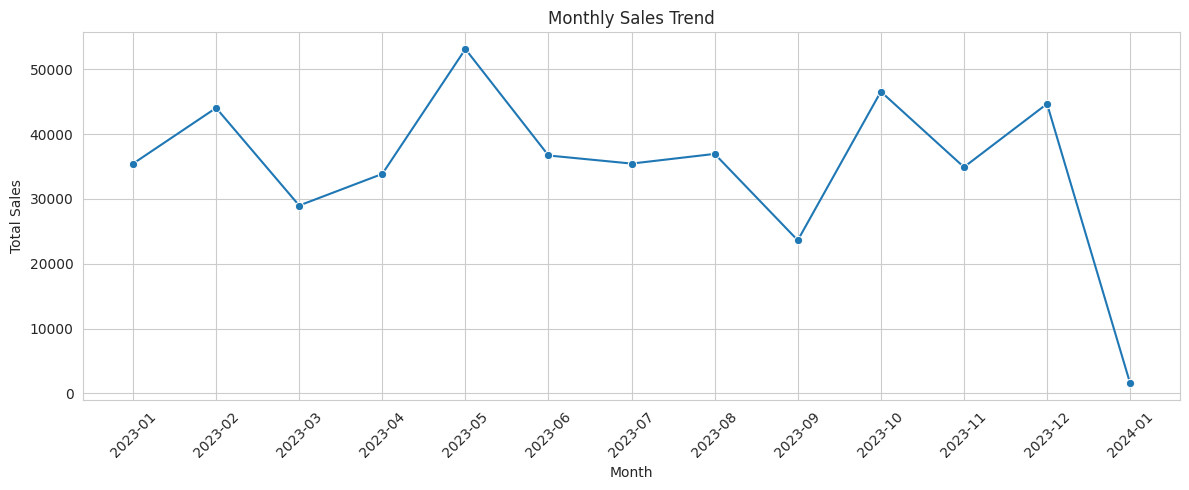

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x='Year-Month',
    y='Total Amount',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The monthly sales trend shows variation in revenue across the observed period. Sales reached their highest level in **2023-05**, while the lowest sales were recorded in **2024-01**.

The fluctuations suggest that sales performance varies across months rather than remaining constant. The peak period could be investigated further to identify whether product demand, customer purchasing behaviour, or transaction volume contributed to the increase.

In [ ]:
quarterly_sales = (
    df.groupby(['Year', 'Quarter'])['Total Amount']
      .sum()
      .reset_index()
)

quarterly_sales['Quarter Label'] = (
    quarterly_sales['Year'].astype(str)
    + '-Q'
    + quarterly_sales['Quarter'].astype(str)
)

quarterly_sales

,Year,Quarter,Total Amount,Quarter Label
0,2023,1,108500,2023-Q1
1,2023,2,123735,2023-Q2
2,2023,3,96045,2023-Q3
3,2023,4,126190,2023-Q4
4,2024,1,1530,2024-Q1


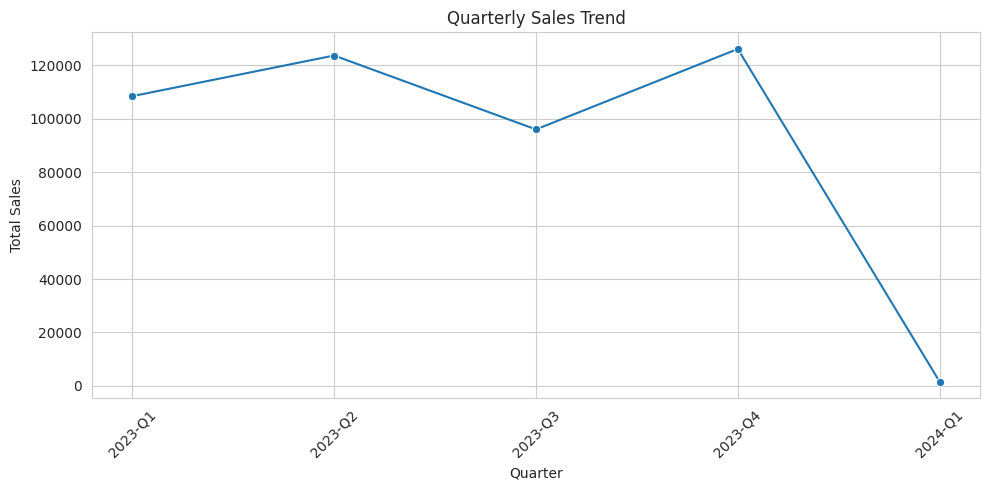

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=quarterly_sales,
    x='Quarter Label',
    y='Total Amount',
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Quarterly sales provide a broader view of the business performance by reducing the short-term fluctuations visible in the monthly data.

The quarter with the highest sales was **2023-Q4**, while **2024-Q1** recorded the lowest sales. This comparison can help identify stronger and weaker periods for planning inventory, promotions, and sales activities.

In [ ]:
print("Total sales:", df['Total Amount'].sum())
print("Highest monthly sales:",
      monthly_sales.loc[
          monthly_sales['Total Amount'].idxmax()
      ])

print("Lowest monthly sales:",
      monthly_sales.loc[
          monthly_sales['Total Amount'].idxmin()
      ])

Total sales: 456000
Highest monthly sales: Year-Month      2023-05
Total Amount      53150
Name: 4, dtype: object
Lowest monthly sales: Year-Month      2024-01
Total Amount       1530
Name: 12, dtype: object


In [ ]:
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = [
    'Under 18',
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

df['Age Group'].value_counts().sort_index()

,count
Age Group,
Under 18,0
18-24,149
25-34,203
35-44,207
45-54,225
55-64,216
65+,0


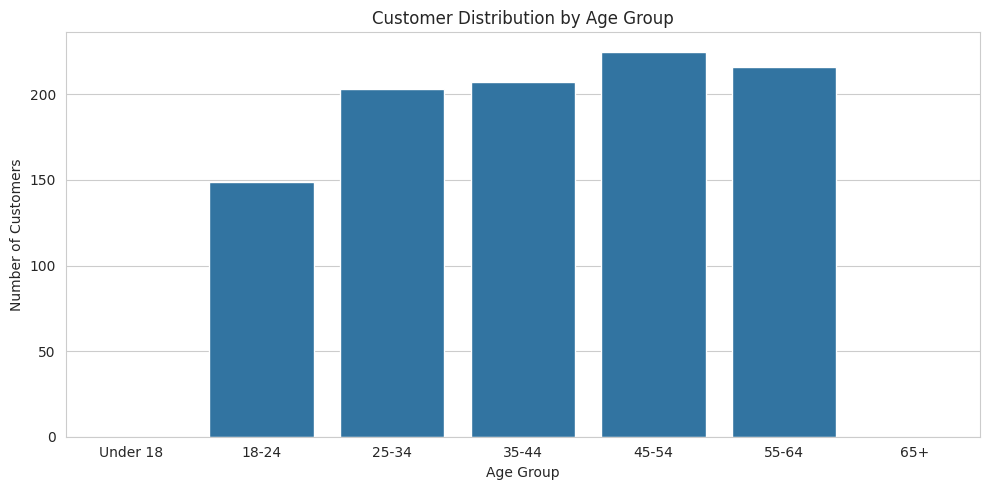

In [ ]:
age_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Observation

The customer base is distributed across several age groups, with age group **45-54** representing the largest share of transactions.

The relatively high representation of this age group suggests that it is an important customer segment for the business. The smaller representation of **18-24** indicates a comparatively lower level of purchasing activity within that segment.

In [ ]:
gender_counts = df['Gender'].value_counts()

display(gender_counts)

,count
Gender,
Female,510
Male,490


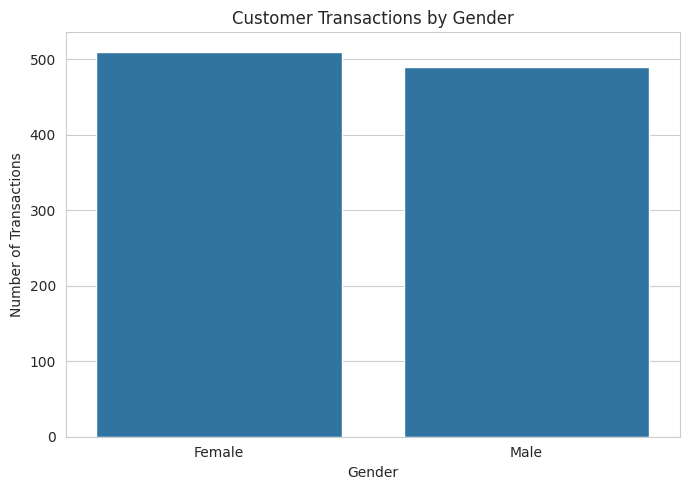

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title('Customer Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.tight_layout()

plt.show()

In [ ]:
gender_percentage = (
    df['Gender']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(gender_percentage)

,proportion
Gender,
Female,51.0
Male,49.0


### Observation

The gender distribution shows that **female gender** accounts for the larger proportion of transactions, representing approximately **51%** of the dataset.

The difference between the two groups indicates that purchasing activity is **more concentrated in female gender**. This information can help the business evaluate whether its current product offerings and marketing strategies are reaching different customer segments effectively.

In [ ]:
age_gender = pd.crosstab(
    df['Age Group'],
    df['Gender']
)

display(age_gender)

Gender,Female,Male
Age Group,,
18-24,72,77
25-34,102,101
35-44,112,95
45-54,115,110
55-64,109,107


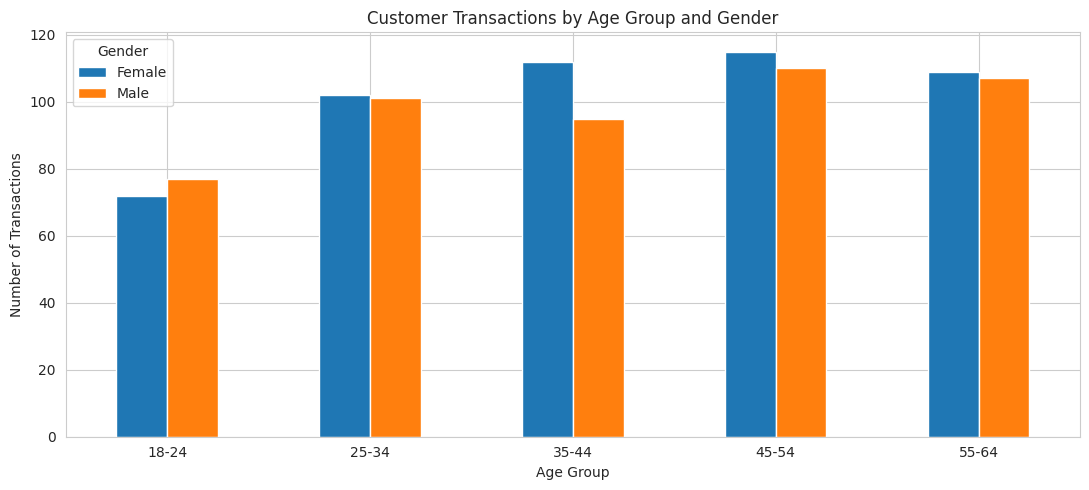

In [ ]:
age_gender.plot(
    kind='bar',
    figsize=(11, 5)
)

plt.title('Customer Transactions by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

### Observation

The age-group and gender comparison shows how purchasing activity is distributed across demographic segments. The pattern indicates that some age groups have a more noticeable representation of one gender than others.

This segmentation can help the business identify demographic groups that may warrant more targeted marketing or product strategies.

In [25]:
category_sales = (
    df.groupby('Product Category')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

display(category_sales)

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


In [27]:
top_categories = category_sales.head(10)

display(top_categories)

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


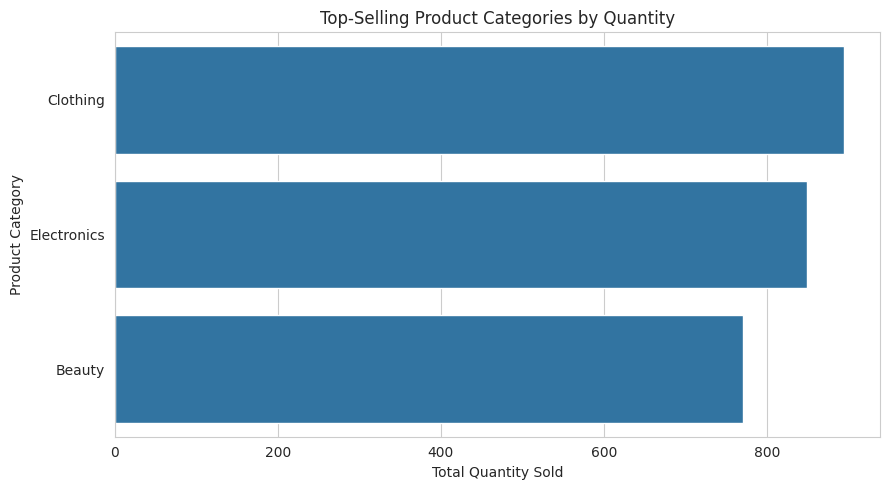

In [28]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title('Top-Selling Product Categories by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### Observation

The analysis shows that **Clothing category** has the highest sales volume, with approximately **894 units** sold. This indicates that this category generates the greatest product demand based on quantity sold.

In comparison, **Beauty category** has the lowest sales volume among the available categories. The difference in sales volume can help the business evaluate inventory requirements and identify categories that may require additional promotional attention.

In [29]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
      .sum()
      .sort_values(ascending=False)
)

display(category_revenue)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


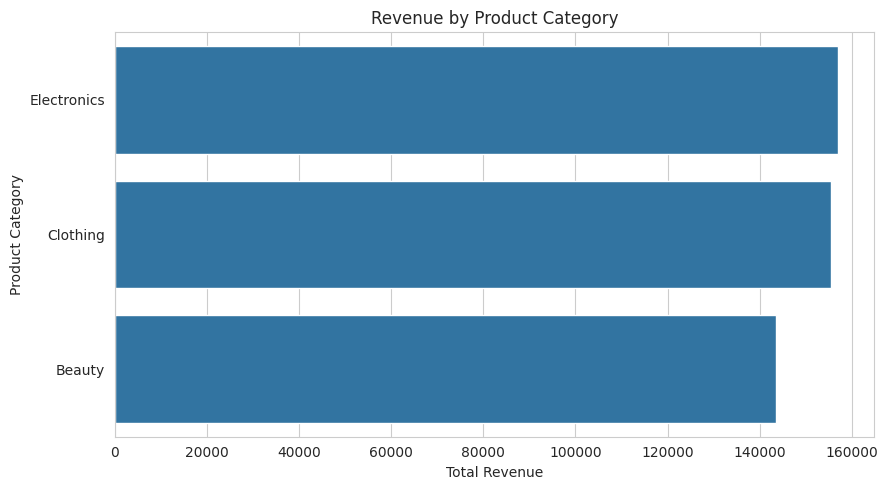

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title('Revenue by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### Observation

The **Electronics** category generates the highest total revenue, contributing approximately **156905** in sales.

Comparing revenue with quantity sold is useful because a category with high sales volume does not necessarily generate the highest revenue. This difference can indicate variations in product pricing and purchasing patterns across categories.

In [31]:
category_summary = df.groupby('Product Category').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Total Amount', 'sum'),
    Average_Price=('Price per Unit', 'mean')
).sort_values('Total_Revenue', ascending=False)

display(category_summary)

,Total_Quantity,Total_Revenue,Average_Price
Product Category,,,
Electronics,849,156905,181.900585
Clothing,894,155580,174.287749
Beauty,771,143515,184.055375


In [32]:
avg_transaction = (
    df.groupby('Product Category')['Total Amount']
      .mean()
      .sort_values(ascending=False)
)

display(avg_transaction)

,Total Amount
Product Category,
Beauty,467.475570
Electronics,458.786550
Clothing,443.247863


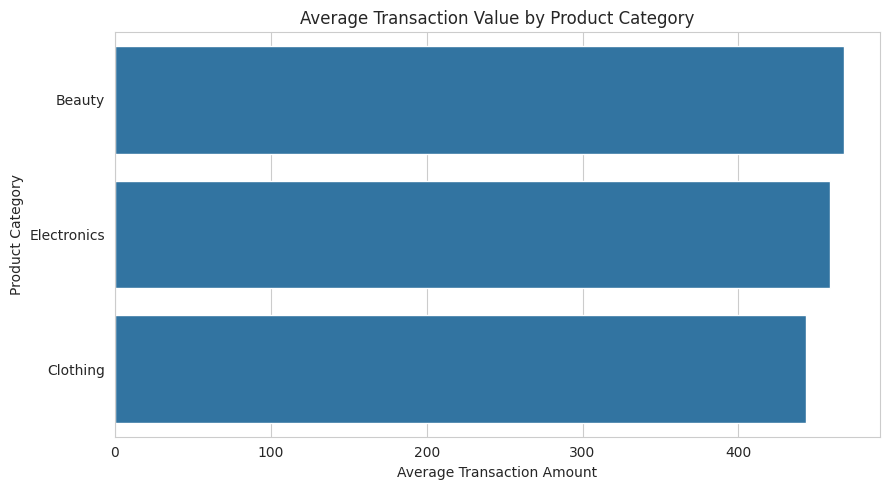

In [33]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=avg_transaction.values,
    y=avg_transaction.index
)

plt.title('Average Transaction Value by Product Category')
plt.xlabel('Average Transaction Amount')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### Observation

The average transaction value differs across product categories. **Beauty** has the highest average transaction amount, while **Clothing** has the lowest.

This suggests that customers spend different amounts per transaction depending on the product category. The business could use this information when designing category-specific promotions, bundles, or upselling strategies.

### Data Limitation

The dataset contains product categories but does not provide individual product names or product IDs. Therefore, the requested top-10 product analysis was performed at the product-category level using total quantity sold.

In [34]:
correlation_data = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
]

correlation_matrix = correlation_data.corr()

display(correlation_matrix)

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


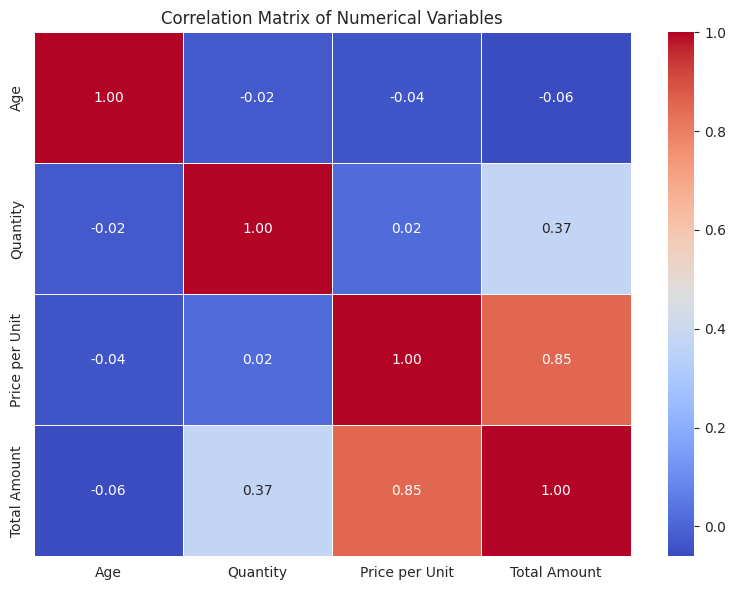

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()

plt.show()

### Observation

The correlation matrix shows the relationships between the main numerical variables in the dataset.

The strongest positive relationship is observed between **Price Per Unit** and **Total Amount**, with a correlation of approximately **0.85**. This indicates that higher values of one variable tend to be associated with higher values of the other.

The relationship between **Quantity** and **Age** is relatively weak, suggesting limited linear association between these variables.

Correlation measures association and does not by itself establish a causal relationship.

In [36]:
age_spending = (
    df.groupby('Age Group', observed=True)['Total Amount']
      .agg(['mean', 'sum', 'count'])
      .reset_index()
)

age_spending.columns = [
    'Age Group',
    'Average Transaction',
    'Total Revenue',
    'Number of Transactions'
]

display(age_spending)

,Age Group,Average Transaction,Total Revenue,Number of Transactions
0,18-24,501.006711,74650,149
1,25-34,478.275862,97090,203
2,35-44,467.801932,96835,207
3,45-54,432.155556,97235,225
4,55-64,417.546296,90190,216


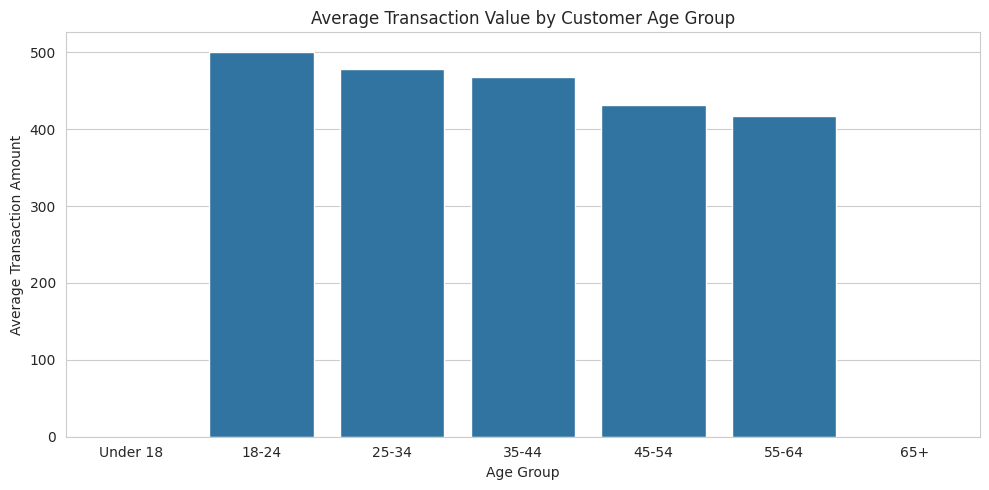

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_spending,
    x='Age Group',
    y='Average Transaction'
)

plt.title('Average Transaction Value by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Amount')

plt.tight_layout()
plt.show()

### Observation

The average transaction value varies across customer age groups. **Age Group of 18-24** has the highest average transaction value, while **Age Group of 55-64** has the lowest.

This suggests that customer age segments may differ in their typical transaction value. The business could use this information to investigate whether different age groups respond differently to product offerings, promotions, or higher-value purchases.

In [38]:
# Overall business metrics

total_revenue = df['Total Amount'].sum()
total_transactions = df['Transaction ID'].nunique()
total_units = df['Quantity'].sum()
average_transaction = df['Total Amount'].mean()

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Transaction Value: {average_transaction:,.2f}")

Total Revenue: 456,000.00
Total Transactions: 1,000
Total Units Sold: 2,514
Average Transaction Value: 456.00


In [39]:
category_summary = df.groupby('Product Category').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Total Amount', 'sum'),
    Average_Transaction=('Total Amount', 'mean'),
    Transactions=('Transaction ID', 'count')
).sort_values('Total_Revenue', ascending=False)

display(category_summary)

,Total_Quantity,Total_Revenue,Average_Transaction,Transactions
Product Category,,,,
Electronics,849,156905,458.786550,342
Clothing,894,155580,443.247863,351
Beauty,771,143515,467.475570,307


In [40]:
best_revenue_category = category_summary['Total_Revenue'].idxmax()
lowest_revenue_category = category_summary['Total_Revenue'].idxmin()

print("Highest revenue category:", best_revenue_category)
print("Lowest revenue category:", lowest_revenue_category)

Highest revenue category: Electronics
Lowest revenue category: Beauty


In [41]:
age_summary = df.groupby(
    'Age Group',
    observed=True
).agg(
    Transactions=('Transaction ID', 'count'),
    Revenue=('Total Amount', 'sum'),
    Average_Transaction=('Total Amount', 'mean')
)

display(age_summary)

,Transactions,Revenue,Average_Transaction
Age Group,,,
18-24,149,74650,501.006711
25-34,203,97090,478.275862
35-44,207,96835,467.801932
45-54,225,97235,432.155556
55-64,216,90190,417.546296


In [42]:
highest_value_age_group = age_summary['Average_Transaction'].idxmax()

print(
    "Age group with the highest average transaction:",
    highest_value_age_group
)

Age group with the highest average transaction: 18-24


In [43]:
monthly_sales = (
    df.groupby(df['Date'].dt.to_period('M'))['Total Amount']
      .sum()
      .sort_values(ascending=False)
)

print("Highest sales month:")
print(monthly_sales.head(1))

print("\nLowest sales month:")
print(monthly_sales.tail(1))

Highest sales month:
Date
2023-05    53150
Freq: M, Name: Total Amount, dtype: int64

Lowest sales month:
Date
2024-01    1530
Freq: M, Name: Total Amount, dtype: int64


# 9. Conclusion

The exploratory data analysis provided several insights into the retail business's sales performance, customer demographics, and product-category behaviour.

The time-series analysis showed that sales vary across months and quarters, indicating that demand is not completely consistent throughout the year. Identifying high- and low-performing periods can help the business improve inventory planning and promotional scheduling.

The customer demographic analysis showed differences in transaction activity across age groups and genders. These patterns can help the business better understand its customer base and develop more targeted marketing strategies.

The product-category analysis revealed differences in both sales volume and revenue generation across categories. Comparing quantity sold with revenue is particularly useful because high-volume categories do not necessarily generate the highest revenue.

Finally, the correlation analysis and additional visualizations provided further insight into relationships between transaction variables and customer spending behaviour.

Overall, the analysis demonstrates that combining sales trends, customer demographics, and product-category performance can support more informed business decisions.

# 10. Actionable Business Recommendations

### 1. Optimize inventory and promotions around high- and low-sales periods

Monthly and quarterly sales analysis shows that revenue varies over time. The business should use historical high-sales periods to increase inventory availability and staffing, while using lower-sales periods for targeted promotions and demand-generation campaigns.

### 2. Prioritize high-revenue product categories

The product-category analysis shows that revenue contribution differs across categories. Management should ensure strong inventory availability for the highest-revenue category while reviewing the performance of lower-revenue categories. Lower-performing categories can be evaluated for pricing, promotion, product assortment, or customer demand before making inventory decisions.

### 3. Develop customer-segment-specific marketing strategies

The demographic analysis shows differences in purchasing activity and average transaction value across age groups and genders. The business can use these patterns to design more targeted campaigns, personalized promotions, and product recommendations for customer segments with higher transaction values or stronger purchasing activity.

In [44]:
print("=" * 50)
print("RETAIL SALES EDA — KEY METRICS")
print("=" * 50)

print(f"Total Revenue       : {df['Total Amount'].sum():,.2f}")
print(f"Total Transactions  : {df['Transaction ID'].nunique():,}")
print(f"Total Units Sold    : {df['Quantity'].sum():,}")
print(f"Average Transaction : {df['Total Amount'].mean():,.2f}")
print(f"Average Customer Age: {df['Age'].mean():.1f}")
print(f"Top Revenue Category: {df.groupby('Product Category')['Total Amount'].sum().idxmax()}")

RETAIL SALES EDA — KEY METRICS
Total Revenue       : 456,000.00
Total Transactions  : 1,000
Total Units Sold    : 2,514
Average Transaction : 456.00
Average Customer Age: 41.4
Top Revenue Category: Electronics
